In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from churn.stats import cramers_v, theils_u, theil_matrix, cramer_matrix

In [2]:
# Load the entire Parquet file into a DataFrame
df = pd.read_parquet("../data/interim/telco_customer_churn_interim.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Bivariate/Multivariate Analysis

### MonthlyCharges and TotalCharges

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

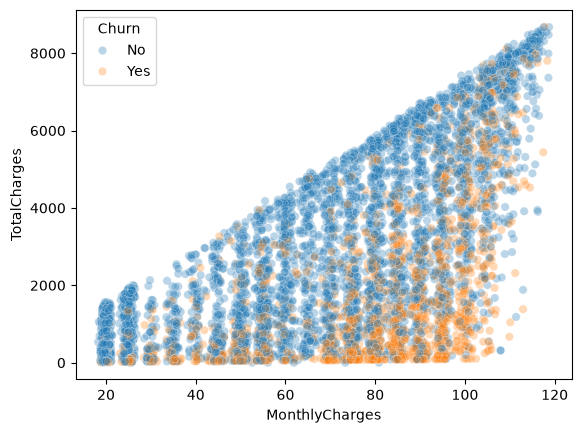

In [3]:
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn",alpha=0.3)

1. A triangle or wedge shape.

* Every point sits below a rising diagonal edge. That edge is about 72 × `MonthlyCharges`, and 72 months is the maximum `tenure`. At a monthly charge of 118 the ceiling is about 8,500, which matches the top-right corner.
* `TotalCharges` ≈ `MonthlyCharges` × `tenure`, so this feature is mostly derived from the other two. A customer's position in the wedge is set by `tenure`: near the bottom means new, near the top edge means a long-standing customer.
* The points sitting at about `0` are the `tenure == 0` customers, whose blank `TotalCharges` was filled with `0`.

2. A fan shape. At low MonthlyCharges the vertical spread is narrow, and it widens as MonthlyCharges rises. The reason is that the same monthly price can belong to a 2-month customer or a 70-month customer. The higher the price, the larger the range of totals that tenure can produce.

3. Churn (orange) is not evenly spread. It piles up in the lower-right: high monthly charge and low total charge. That means short tenure combined with an expensive plan, such as new fibre-optic customers. The top of the wedge, long tenure, is mostly blue. Since the churner is plotted over the retained customers, the density of orange in the lower-right is probably understated.


A dense cluster near MonthlyCharges ≈ 20-30. These are phone-only customers with no internet service, which is the cheapest tier. They are mostly blue (retained) and spread across all tenures.


<Axes: xlabel='PhoneService', ylabel='MonthlyCharges'>

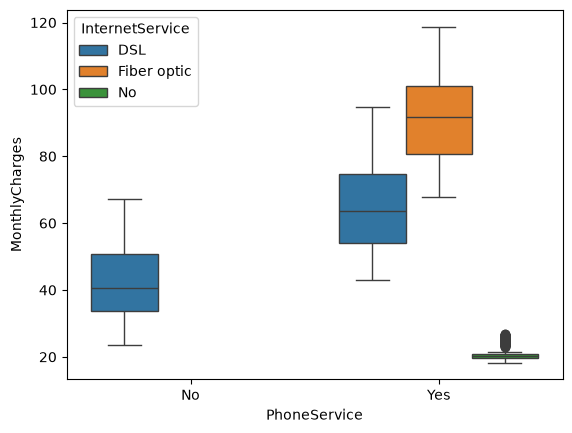

In [4]:
sns.boxplot(data=df, x="PhoneService", y="MonthlyCharges", hue="InternetService")

In [5]:
temp_df = df.loc[df['MonthlyCharges']<=30, ['PhoneService', 'InternetService', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].copy()

In [6]:
pd.crosstab(temp_df['PhoneService'], temp_df['InternetService'])

InternetService,DSL,No
PhoneService,,
No,127,0
Yes,0,1526


In [7]:
# Calculate between two specific columns
cov_pair = df['MonthlyCharges'].cov(df['TotalCharges'])
corr_pair = df['MonthlyCharges'].corr(df['TotalCharges'])
print(f"Pairwise Covariance: {cov_pair}")
print(f"Pairwise Correlation: {corr_pair}")

Pairwise Covariance: 44415.23367830183
Pairwise Correlation: 0.651173831578784


Correlation of 0.65. This is clearly positive but not near 1. If tenure were fixed, the two would be perfectly linked. Tenure varies from 0 to 72, and that is what loosens the relationship.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

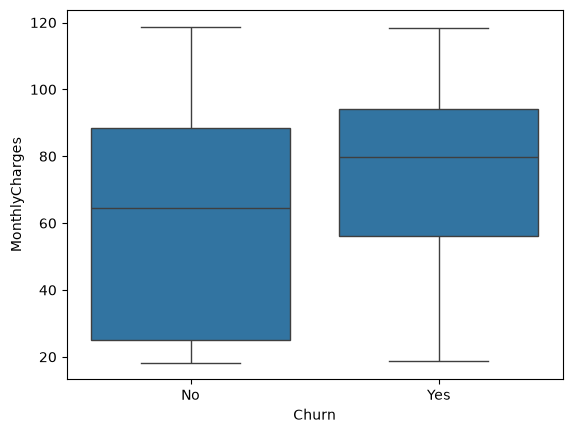

In [8]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

<Axes: xlabel='Churn', ylabel='TotalCharges'>

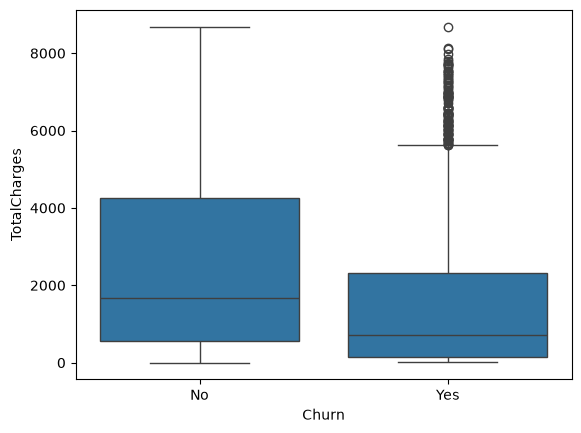

In [9]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")

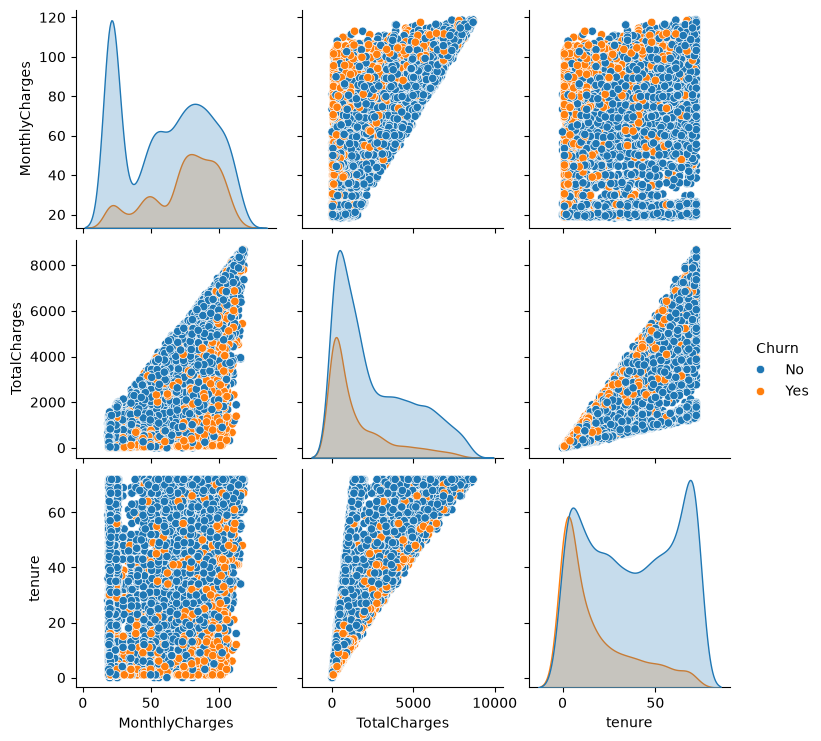

In [10]:
sns.pairplot(df, hue="Churn", vars=["MonthlyCharges", "TotalCharges", "tenure"])

On checking `MonthlyCharges` vs `tenure`, churn is higher for high `MonthlyCharges` and low  `tenure`.

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges_per_month'>

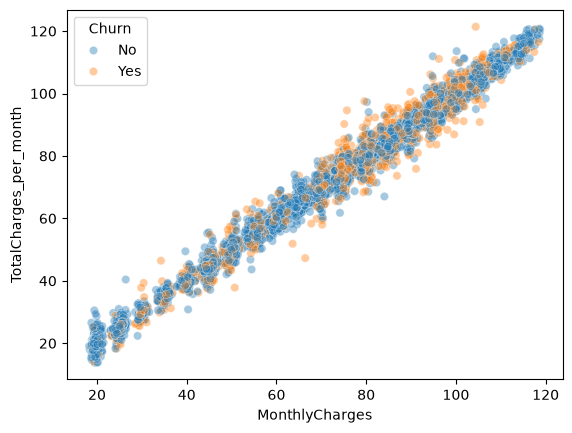

In [11]:
temp_df = df.loc[df['tenure']>0, ['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].copy()
temp_df['TotalCharges_per_month'] = temp_df['TotalCharges'] / temp_df['tenure']
sns.scatterplot(data=temp_df, x="MonthlyCharges", y="TotalCharges_per_month", hue="Churn", alpha=0.4)


In [12]:
temp_df['MonthlyCharges'].corr(temp_df['TotalCharges_per_month'])

np.float64(0.9962373123907751)

Good correlation between `MonthlyCharges` and `TotalCharges_per_month`

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

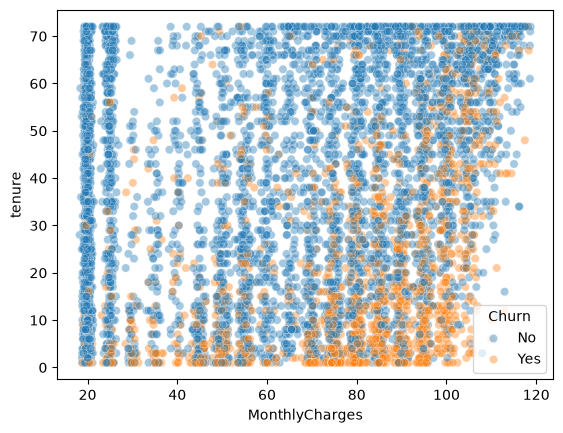

In [13]:
sns.scatterplot(data=temp_df, x="MonthlyCharges", y="tenure", hue="Churn", alpha=0.4)

> i have decided to remove the column `TotalCharges` and keep `MonthlyCharges` and `tenure` as these 2 columns covers the info in `TotalCharges` and the colinearlity is also taken care of in this way between `TotalCharges` and  `MonthlyCharges`.

In [14]:
df.drop(columns=['TotalCharges'], inplace=True, errors='ignore')

#### Bivariate Analysis of Categorical Features on Churn Rate

In [15]:
df.groupby(['Contract'])['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [16]:
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)
overall = df["Churn_num"].mean()          # baseline, about 0.265

In [17]:
overall  ## baseline churn value

np.float64(0.2653698707936959)

In [18]:
# Check 1: churn rate + group size for one feature

summary = (
    df.groupby("Contract")["Churn_num"]
      .agg(churn_rate="mean", n="count")
      .sort_values("churn_rate", ascending=False)
)

# summary
# The mean of a 1/0 column is the proportion of 1s, so mean is the churn rate. n tells you how much evidence is behind each rate.

In [19]:
summary

,churn_rate,n
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


By grouping the data by specific categorical columns and taking the mean of this binary column `Churn`, you derive the exact churn proportion for each subgroup.

In [20]:
# Check 2: plot against the baseline

def plot_churn_rate(col, data=df):
    order = data.groupby(col)["Churn_num"].mean().sort_values(ascending=False).index
    ax = sns.barplot(data=data, x=col, y="Churn_num", order=order)   # bars = mean, whiskers = 95% CI
    ax.axhline(overall, color="red", linestyle="--", label=f"overall {overall:.1%}")
    ax.set_ylabel("Churn rate")
    ax.legend()
    plt.xticks(rotation=20)
    plt.show()

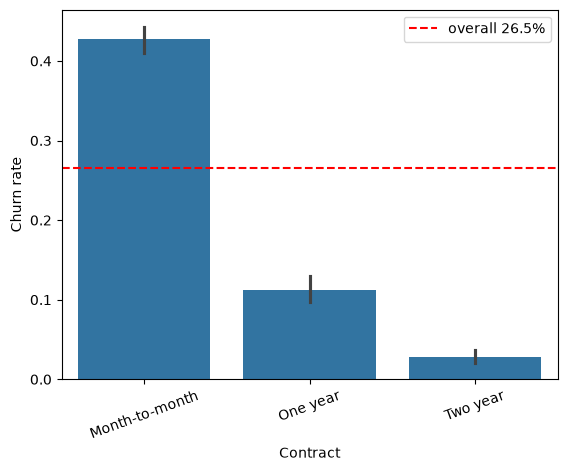

In [21]:
plot_churn_rate("Contract")

In [22]:
cat_cols = [c for c in df.select_dtypes(exclude="number").columns
            if c not in ("customerID", "Churn")] + ["SeniorCitizen"]

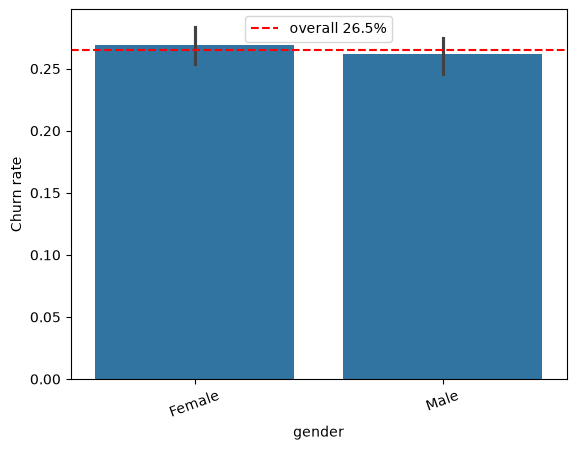

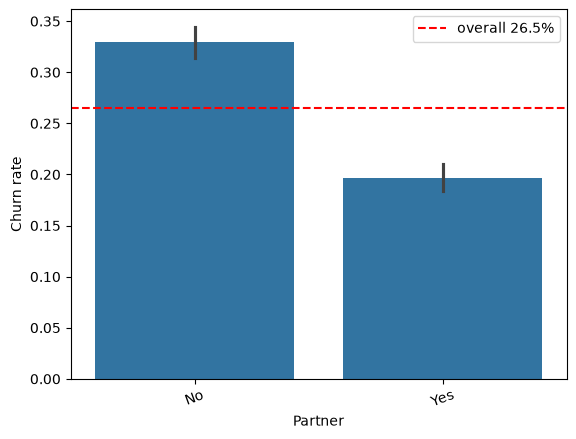

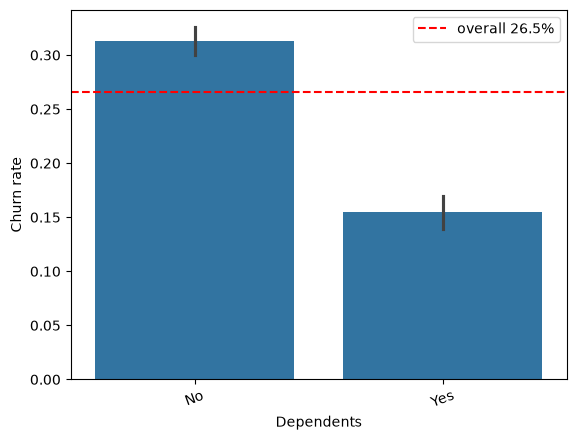

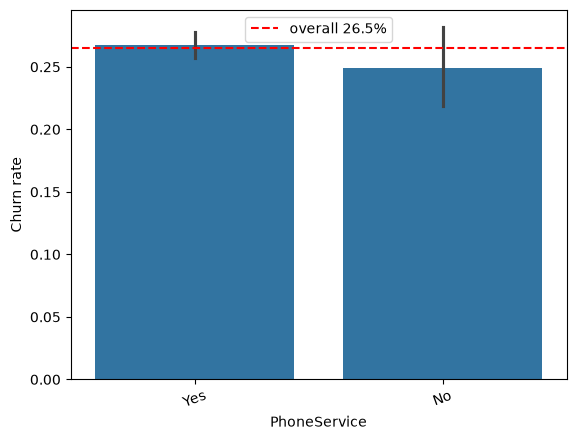

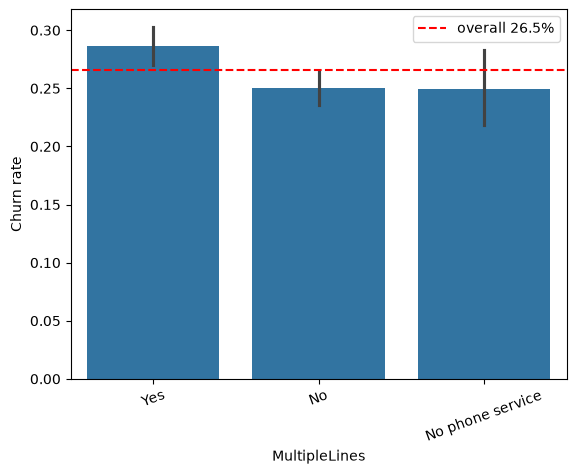

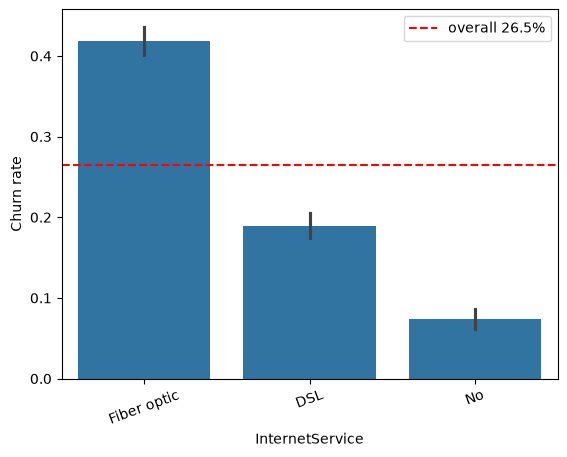

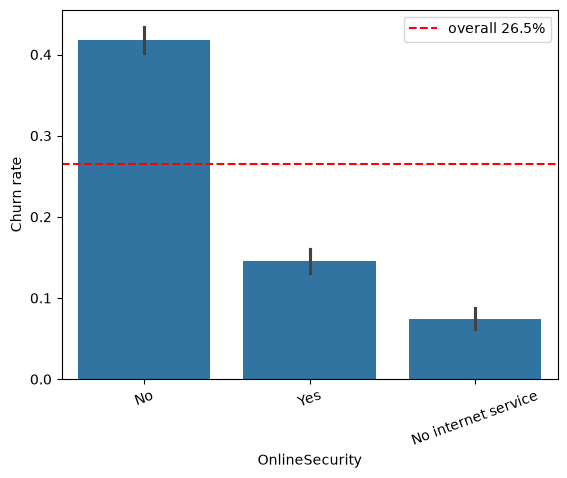

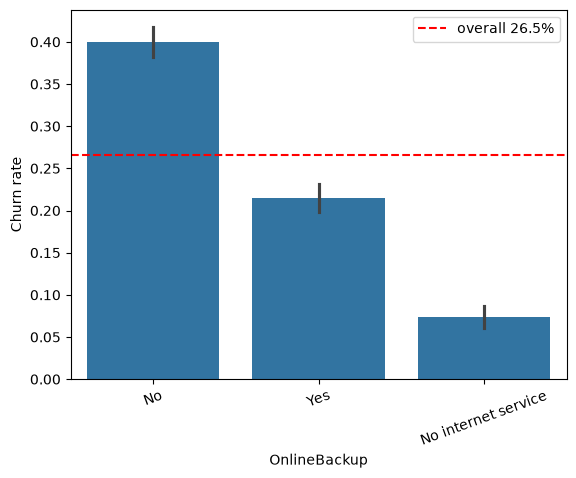

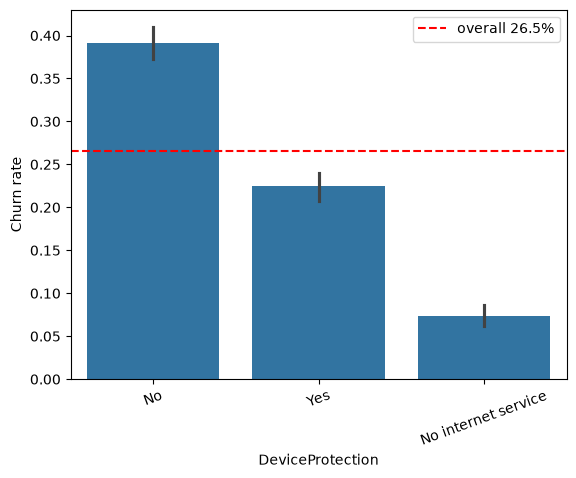

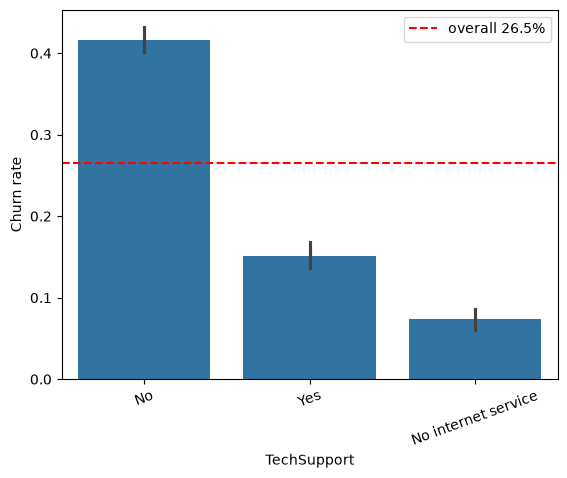

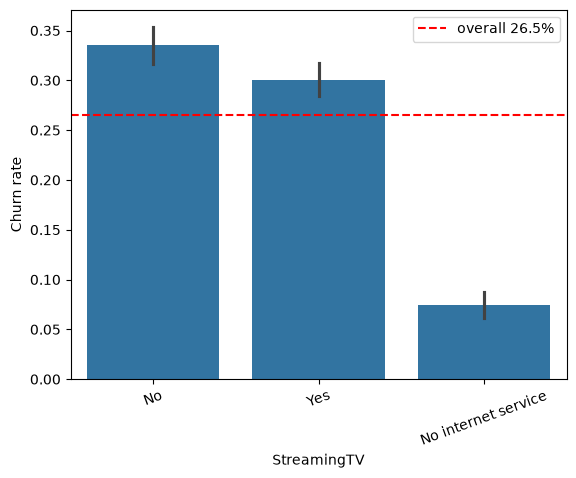

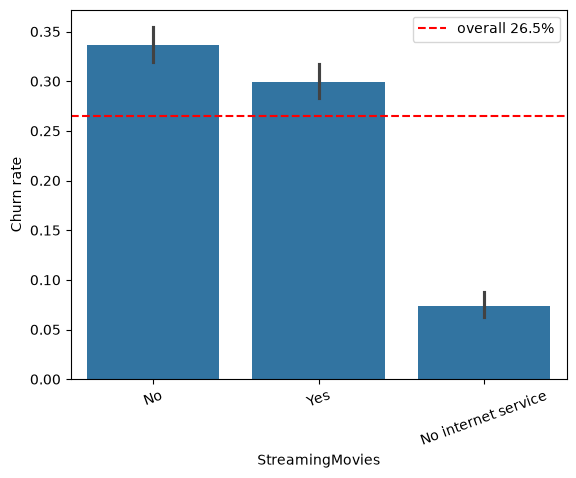

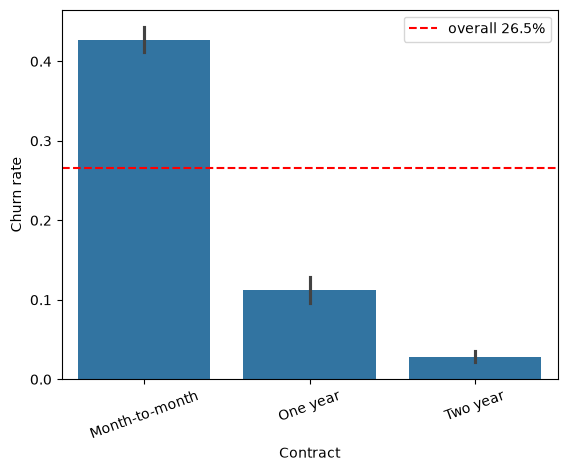

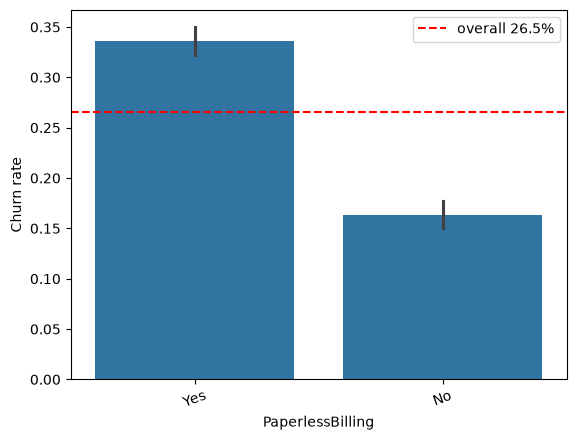

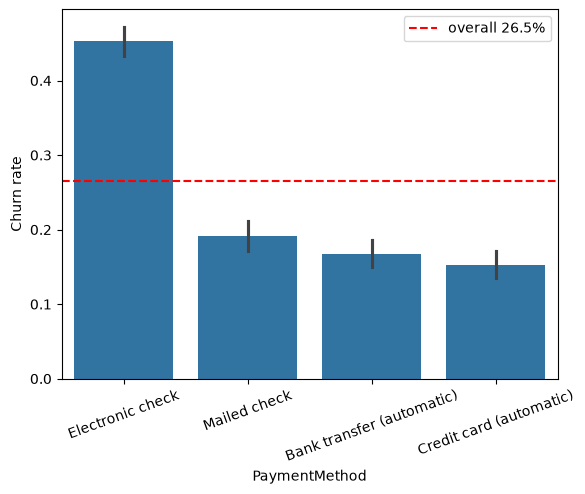

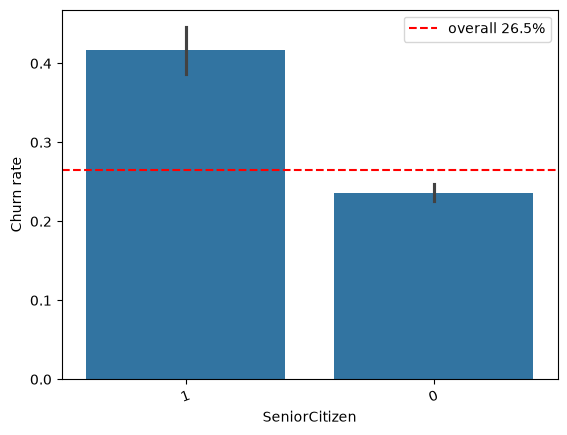

In [23]:
for col in cat_cols:
    plot_churn_rate(col)

You interpret these graphs by looking at the vertical distance between the top of each bar and the red dashed baseline. The red line represents the "average" customer; the bars show how specific subgroups deviate from that average.

**Maximum Impact (High Predictive Signal)**
A categorical feature has a massive impact on churn when you see wild variation in the heights of its bars.

* **Visual Cue:** You will see a "staircase" effect or drastic peaks and valleys. Some categories will tower above the red line, while others will sit far below it.
* **What it Means:** The feature strongly separates customer behavior. Knowing which category a customer falls into drastically changes their probability of churning compared to a blind guess.
* **Example:** In a `Contract` graph, a "Month-to-month" bar might spike to 42% (way above the 26.5% baseline), while the "Two-year" bar drops to 3%. This massive gap means `Contract` is a highly valuable predictor for your model.

**Least Impact (Low Predictive Signal)**
A feature has little to no impact when all of its categories behave exactly like the overall average.

* **Visual Cue:** The "flatline." Every bar in the chart stops right at or very near the red dashed baseline.
* **What it Means:** The feature is essentially noise. Knowing this specific customer detail gives you no new mathematical leverage to predict if they will leave.
* **Example:** In a `Gender` graph, if the "Male" bar sits at 26.2% and the "Female" bar sits at 26.8%, both are practically touching the baseline. Dropping this column from your dataset entirely will likely improve model performance by removing dead weight.

The red dashed baseline is **26.5%** churn. All of this is association, not proof that a category causes churn.

**gender:** Female (26.9%) and Male (26.2%) both sit on the baseline. Gender tells you nothing about churn and is the best candidate to drop.

**Partner:** Customers without a partner churn at 33.0% and those with one at 19.7%, a gap of about 13 points. Partnered customers are probably more settled or on shared household plans, which makes leaving harder. Partner is also likely linked to tenure, so some of this effect may overlap with it.

**Dependents:** Customers with dependents churn at about half the rate of those without (15.5% vs 31.3%). Families are less likely to switch providers, probably because switching means disrupting several people's services.

**PhoneService:** Yes is 26.7% and No is 24.9%, both close to the baseline. The No group is small (n=682), so its confidence interval is wide. Having phone service on its own has almost no effect on churn.

**MultipleLines:** The three groups range from 24.9% to 28.6%, all close to the baseline. Multiple lines go slightly with higher churn, likely because they raise the monthly bill. The signal is weak.

**InternetService:** This is one of the strongest charts. Fiber optic churns at 41.9%, DSL at 19.0% and no internet at 7.4%. Fiber customers pay the highest monthly charges, which could point to price or service-quality problems; customers with no internet are cheap, low-engagement accounts that rarely leave.

**OnlineSecurity:** Customers without online security churn at 41.8% and those with it at 14.6%, nearly a 3× gap. Add-on services seem to make customers stay (or are bought by customers who already plan to stay). The 7.4% "No internet service" bar is the same group as in InternetService.

**OnlineBackup:** No is 39.9% and Yes is 21.5%. It shows the same add-ons-mean-loyalty pattern as OnlineSecurity, with a smaller gap.

**DeviceProtection:** No is 39.1% and Yes is 22.5%, almost the same as OnlineBackup. The protection and backup add-ons behave alike, so they are likely related to each other.

**TechSupport:** No is 41.6% and Yes is 15.2%, nearly as strong as OnlineSecurity. Customers who have tech support may have their problems fixed instead of leaving over them.

**StreamingTV:** No is 33.5% and Yes is 30.1%, so subscribing barely changes churn. The chart only looks different from the baseline because of the 7.4% "No internet service" bar; among internet customers, streaming is a weak signal.

**StreamingMovies:** It looks almost exactly like StreamingTV (33.7% vs 29.9%). Entertainment add-ons, unlike protection or support add-ons, don't keep customers. The two streaming columns are probably highly associated with each other.

**Contract:** This is the strongest chart. Month-to-month customers churn at 42.7%, one-year at 11.3% and two-year at 2.8%, a 15× range. Longer contracts make leaving harder and attract committed customers, so this is likely the top predictor.

**PaperlessBilling:** Paperless customers churn at about twice the rate of the rest (33.6% vs 16.3%). Going paperless is unlikely to cause churn itself. It probably reflects younger, more digitally active customers on month-to-month plans who find switching easy.

**PaymentMethod:** Electronic check stands out at 45.3%. The other three methods are close to each other at 15–19%. The two automatic methods churn least, perhaps because a customer has to actively pay by electronic check each month, which gives them a regular moment to reconsider. In practice this feature is close to a yes/no flag for electronic check.

**SeniorCitizen:** Seniors churn at 41.7% and non-seniors at 23.6%, a large gap. Seniors are only 16% of customers (n=1,142), so the effect is real but covers fewer people. It may be partly explained by seniors being more often on fiber or month-to-month plans, which you can check with a crosstab.

**Overall ranking:**
- **Strongest:** Contract, InternetService, PaymentMethod, OnlineSecurity, TechSupport and SeniorCitizen.
- **Moderate:** Partner, Dependents, PaperlessBilling, OnlineBackup and DeviceProtection.
- **Little or none:** gender, PhoneService, MultipleLines, StreamingTV and StreamingMovies.

The "No internet service" level is repeated across six service columns, so those columns share information. Your Cramér's V and Theil's U heatmaps in the next cells should confirm both the ranking and that overlap.

## Bivariate Analysis Methodology

The provided code calculates the baseline churn rate at approximately 26.5% by converting the categorical "Yes"/"No" target into a binary 1/0 variable. By grouping the data by specific categorical columns and taking the mean of this binary column, you derive the exact churn proportion for each subgroup. The sample size (`n`) dictates the statistical confidence of that specific rate.

## Categorical Feature Impacts

Based on the structure of the Telco Customer Churn dataset, here is how the primary categorical columns impact customer retention:

* **Contract**: This is traditionally the strongest predictor. Your code output demonstrates that Month-to-month contracts have a high churn rate of 42.7%, whereas One-year (11.2%) and Two-year (2.8%) contracts retain customers successfully.


* **InternetService**: Customers with Fiber Optic service generally show much higher churn compared to DSL or No Internet. This often indicates pricing sensitivity or regional service reliability issues.
* **PaymentMethod**: Users paying via Electronic Check churn at drastically higher rates than those relying on automated methods like Credit Card or Bank Transfer. Manual payment friction strongly correlates with account cancellation.
* **Demographics (SeniorCitizen, Partner, Dependents)**: Customers flagged as Senior Citizens typically exhibit a higher churn probability. Conversely, customers with partners or dependents demonstrate lower churn, likely due to the logistical friction of migrating family households or multi-line plans.
* **Value-Added Services (TechSupport, OnlineSecurity)**: Customers lacking supplementary services like Tech Support, Online Security, Online Backup, or Device Protection are highly vulnerable to churn. Bundled services create ecosystem "stickiness."


In [24]:
v, p = cramers_v(df["Contract"], df["Churn"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'Contract' and 'Churn' are DEPENDENT.
Cramer's V: 0.4098, p-value: 0.0000


In [25]:
v, p = cramers_v( y=df["Churn"], x=df["Contract"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'Contract' and 'Churn' are DEPENDENT.
Cramer's V: 0.4098, p-value: 0.0000


In [28]:
cat_cols = [c for c in df.select_dtypes(exclude="number").columns
            if c not in ("customerID")] + ["SeniorCitizen"]
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

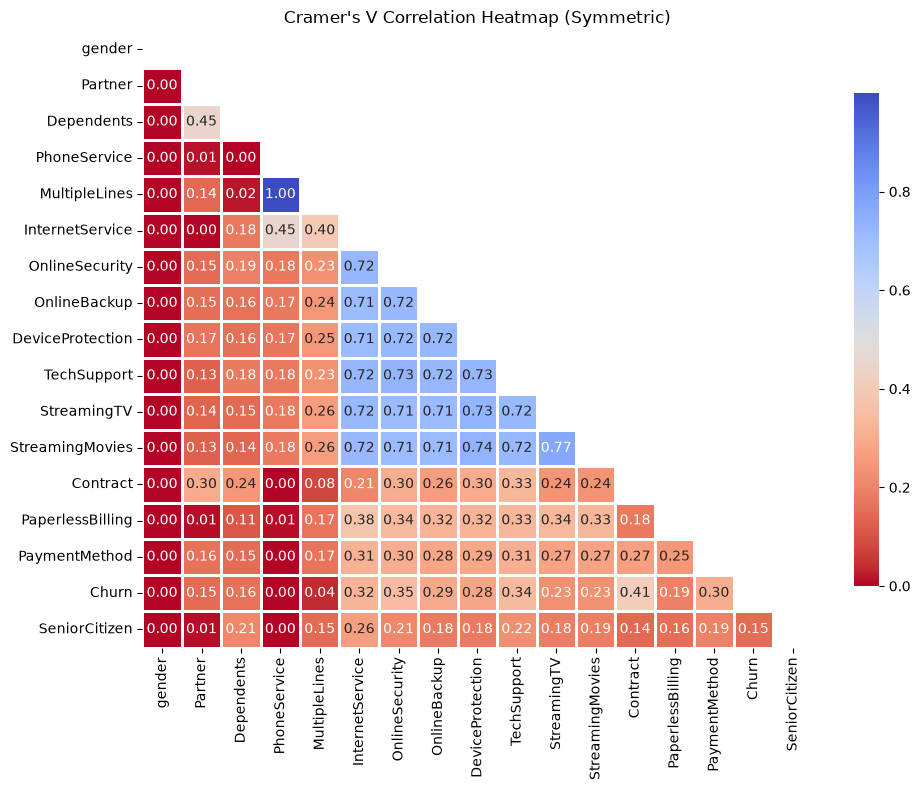

In [29]:
cramer_matrix(data=df, columns=cat_cols)

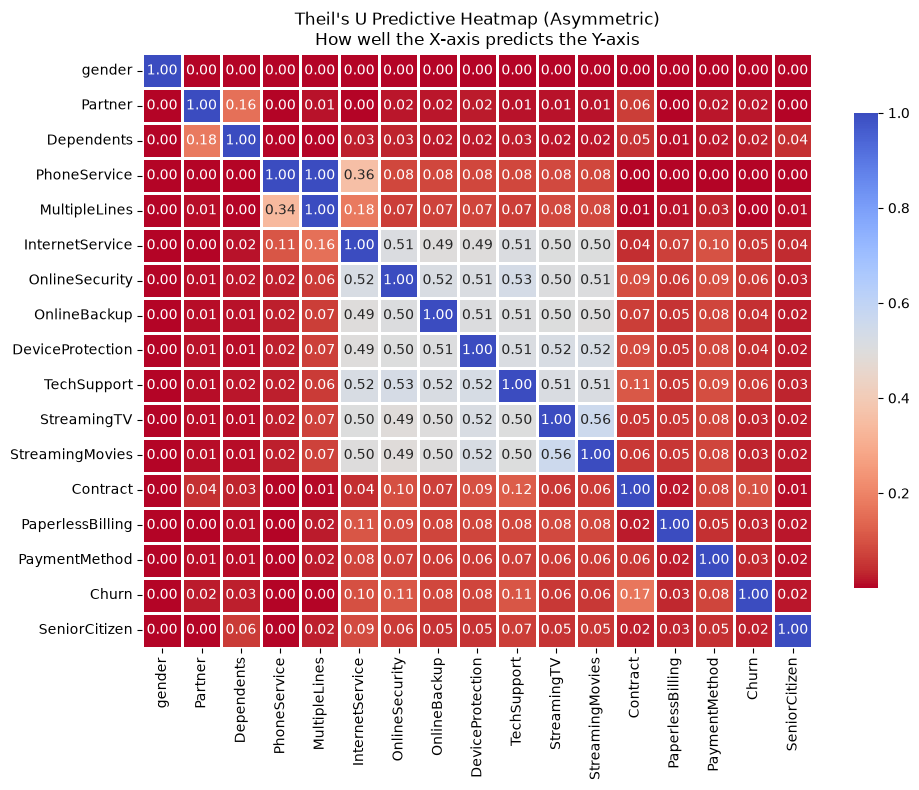

In [30]:
theil_matrix(data=df, columns=cat_cols)

#### Check Streming TV and Streaming Movie Services
Based on the bar graphs showing imapct of **Streming TV** and **Streaming Movie** on churn_rate both have the same impact. Also, the cramer-value and theils_U show how associated both these columns are so one of them can be removed to avoid multi-colinearity.

So we can drop either one of them, I will be dropping `StreamingMovies`.

In [ ]:
v, p = cramers_v( y=df["StreamingTV"], x=df["StreamingMovies"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'StreamingMovies' and 'StreamingTV' are DEPENDENT.
Cramer's V: 0.7710, p-value: 0.0000


In [ ]:
theils_u(y=df["StreamingTV"], x=df["StreamingMovies"])  

np.float64(0.5623841367162747)

In [33]:
df.drop(columns=['StreamingMovies'], inplace=True, errors='ignore')

### Check Gender

based on the churn_rate baseline, `Gender` both sit on the baseline and have no imapct on Churn.

Theil-U and Cramer-V also show that these 2 are independent so `gender` column can be dropped from the analysis.

In [35]:
v, p = cramers_v( y=df["Churn"], x=df["gender"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.46983) >= 0.05: Fail to reject the Null Hypothesis. 'gender' and 'Churn' are INDEPENDENT.
Cramer's V: 0.0000, p-value: 0.4698


In [34]:
theils_u(y=df["Churn"], x=df["gender"])  

np.float64(6.409086889696102e-05)

In [36]:
df.drop(columns=['gender'], inplace=True, errors='ignore')

#### Check `PhoneService` and `MultipleLines`

Both have simialr type of churn-rate basline.  Phone Service and Baseline are highly associated. So one of them can be dropped.




In [38]:
v, p = cramers_v( y=df["PhoneService"], x=df["MultipleLines"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'MultipleLines' and 'PhoneService' are DEPENDENT.
Cramer's V: 0.9999, p-value: 0.0000


In [39]:
theils_u(y=df["PhoneService"], x=df["MultipleLines"])  

np.float64(1.0)

In [40]:
theils_u(x=df["MultipleLines"],y=df["PhoneService"])  

np.float64(1.0)

In [37]:
v, p = cramers_v( y=df["Churn"], x=df["MultipleLines"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00346) < 0.05: Reject the Null Hypothesis. 'MultipleLines' and 'Churn' are DEPENDENT.
Cramer's V: 0.0364, p-value: 0.0035


In [41]:
v, p = cramers_v( y=df["Churn"], x=df["PhoneService"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.31625) >= 0.05: Fail to reject the Null Hypothesis. 'PhoneService' and 'Churn' are INDEPENDENT.
Cramer's V: 0.0008, p-value: 0.3162


In [42]:
theils_u(y=df["Churn"], x=df["PhoneService"])  

np.float64(0.00012471416034482154)

In [43]:
theils_u(y=df["Churn"], x=df["MultipleLines"])  

np.float64(0.00138483788353745)

Based on the above studies, I have decided to drop `PhoneService`.

In [44]:
df.drop(columns=['PhoneService'], inplace=True, errors='ignore')